<a href="https://colab.research.google.com/github/Springboard429/B12---PlantDocBot-AI-Plant-Disease-Diagnosis-via-Chat-and-Image-Upload/blob/Krishna-Raju/plantdoc_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Path to your uploaded zip (change this to your actual path)
zip_path = '/content/drive/MyDrive/plantvillage.zip'
extract_path = '/content/dataset'

# 3. Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset is ready at:", extract_path)

Mounted at /content/drive
Dataset is ready at: /content/dataset


In [ ]:
import pandas as pd
import os
from pathlib import Path

# Updated path to look inside the 'PlantVillage' subfolder
data_root = Path('/content/dataset/PlantVillage')

image_data = []

# List of valid image extensions
valid_extensions = ('.jpg', '.jpeg', '.png', '.JPG')

# Traverse through split folders (e.g., 'train', 'val', 'test')
for split_folder_name in os.listdir(data_root):
    split_folder_path = data_root / split_folder_name
    if split_folder_path.is_dir():
        # Traverse through disease folders within each split
        for disease_folder_name in os.listdir(split_folder_path):
            disease_folder_path = split_folder_path / disease_folder_name
            if disease_folder_path.is_dir():
                # Traverse through image files within each disease folder
                for image_file_name in os.listdir(disease_folder_path):
                    if image_file_name.lower().endswith(valid_extensions): # .lower() for case-insensitive check
                        image_data.append({
                            'image_path': str(disease_folder_path / image_file_name),
                            'label': disease_folder_name  # This will now be the disease name
                        })

df = pd.DataFrame(image_data)

print(f"Total images found: {len(df)}")
print("\nFirst few rows of your new Data Frame:")
print(df.head())

# Check how many images you have per disease
print("\nImages per disease:")
print(df['label'].value_counts())

Total images found: 54305

First few rows of your new Data Frame:
                                          image_path  \
0  /content/dataset/PlantVillage/train/Tomato___T...   
1  /content/dataset/PlantVillage/train/Tomato___T...   
2  /content/dataset/PlantVillage/train/Tomato___T...   
3  /content/dataset/PlantVillage/train/Tomato___T...   
4  /content/dataset/PlantVillage/train/Tomato___T...   

                                    label  
0  Tomato___Tomato_Yellow_Leaf_Curl_Virus  
1  Tomato___Tomato_Yellow_Leaf_Curl_Virus  
2  Tomato___Tomato_Yellow_Leaf_Curl_Virus  
3  Tomato___Tomato_Yellow_Leaf_Curl_Virus  
4  Tomato___Tomato_Yellow_Leaf_Curl_Virus  

Images per disease:
label
Orange___Haunglongbing_(Citrus_greening)              5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus                5357
Soybean___healthy                                     5090
Peach___Bacterial_spot                                2297
Tomato___Bacterial_spot                               2127
Tomato___La

Frequency Distribution Visualization

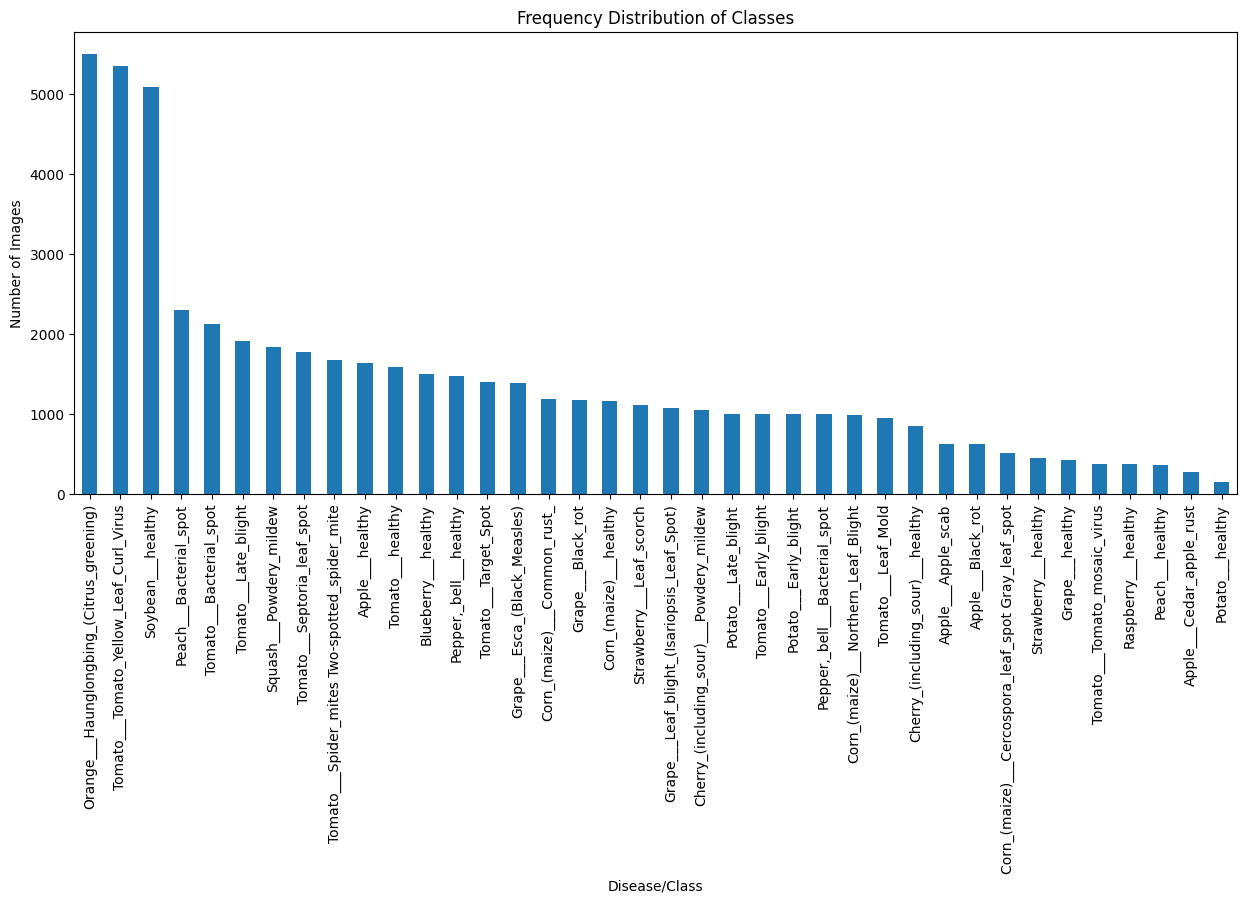

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', figsize=(15,6))
plt.title("Frequency Distribution of Classes")
plt.xlabel("Disease/Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.show()


Image Resolution & Spatial Dimension

In [ ]:
import cv2

widths, heights, ratios = [], [], []
for path in df['image_path'].sample(1000):  # sample for efficiency
    img = cv2.imread(path)


CLS DISTRIBUTION ANALYSIS

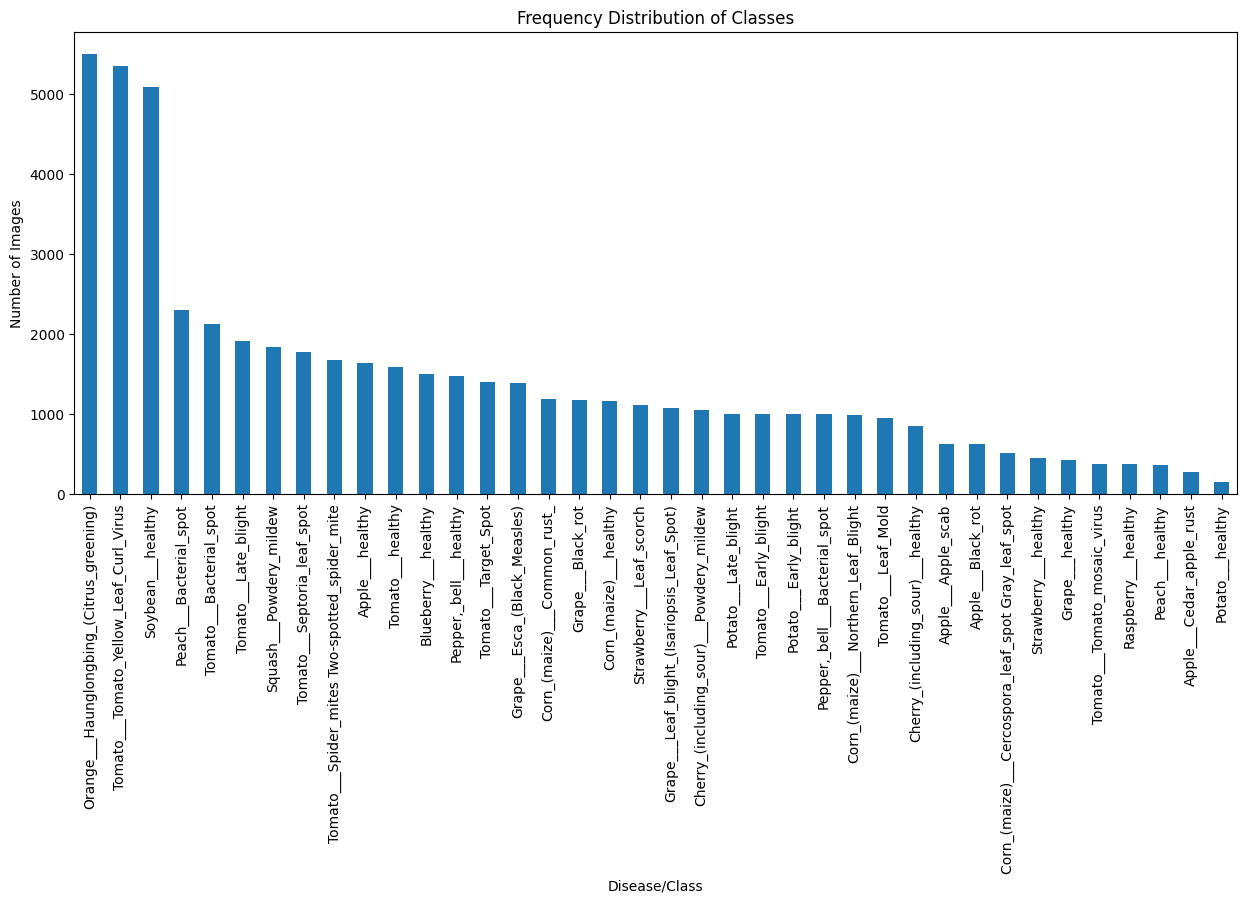

Class distribution summary:
label
Orange___Haunglongbing_(Citrus_greening)              5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus                5357
Soybean___healthy                                     5090
Peach___Bacterial_spot                                2297
Tomato___Bacterial_spot                               2127
Tomato___Late_blight                                  1909
Squash___Powdery_mildew                               1835
Tomato___Septoria_leaf_spot                           1771
Tomato___Spider_mites Two-spotted_spider_mite         1676
Apple___healthy                                       1645
Tomato___healthy                                      1591
Blueberry___healthy                                   1502
Pepper,_bell___healthy                                1478
Tomato___Target_Spot                                  1404
Grape___Esca_(Black_Measles)                          1383
Corn_(maize)___Common_rust_                           1192
Grape___Black_rot     

In [ ]:
# --- Class Distribution Analysis ---
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df contains your dataset with columns ['image_path', 'label']
# Example: df = pd.read_csv("dataset_labels.csv")

# Frequency distribution
class_counts = df['label'].value_counts()

# Plot
plt.figure(figsize=(15,6))
class_counts.plot(kind='bar')
plt.title("Frequency Distribution of Classes")
plt.xlabel("Disease/Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.show()

# Print summary
print("Class distribution summary:")
print(class_counts)


IMG RESOLTN,ASPECT RATIO

Resolution statistics:
        width  height  aspect_ratio
count  1000.0  1000.0        1000.0
mean    256.0   256.0           1.0
std       0.0     0.0           0.0
min     256.0   256.0           1.0
25%     256.0   256.0           1.0
50%     256.0   256.0           1.0
75%     256.0   256.0           1.0
max     256.0   256.0           1.0


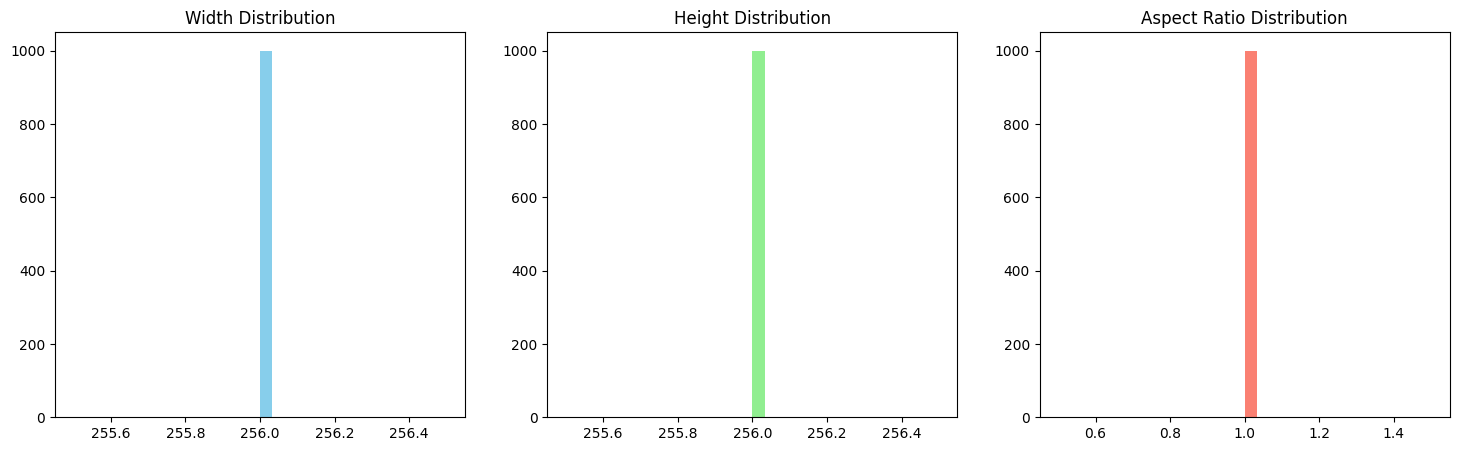

In [ ]:
# --- Image Resolution and Aspect Ratio Analysis ---
import cv2
import numpy as np

widths, heights, ratios = [], [], []

# Sample subset for efficiency (you can remove .sample if dataset is small)
for path in df['image_path'].sample(1000, random_state=42):
    img = cv2.imread(path)
    if img is not None:
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)
        ratios.append(w/h)

# Convert to DataFrame
res_df = pd.DataFrame({
    "width": widths,
    "height": heights,
    "aspect_ratio": ratios
})

# Summary statistics
print("Resolution statistics:")
print(res_df.describe())

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].hist(res_df['width'], bins=30, color='skyblue')
axes[0].set_title("Width Distribution")

axes[1].hist(res_df['height'], bins=30, color='lightgreen')
axes[1].set_title("Height Distribution")

axes[2].hist(res_df['aspect_ratio'], bins=30, color='salmon')
axes[2].set_title("Aspect Ratio Distribution")

plt.show()


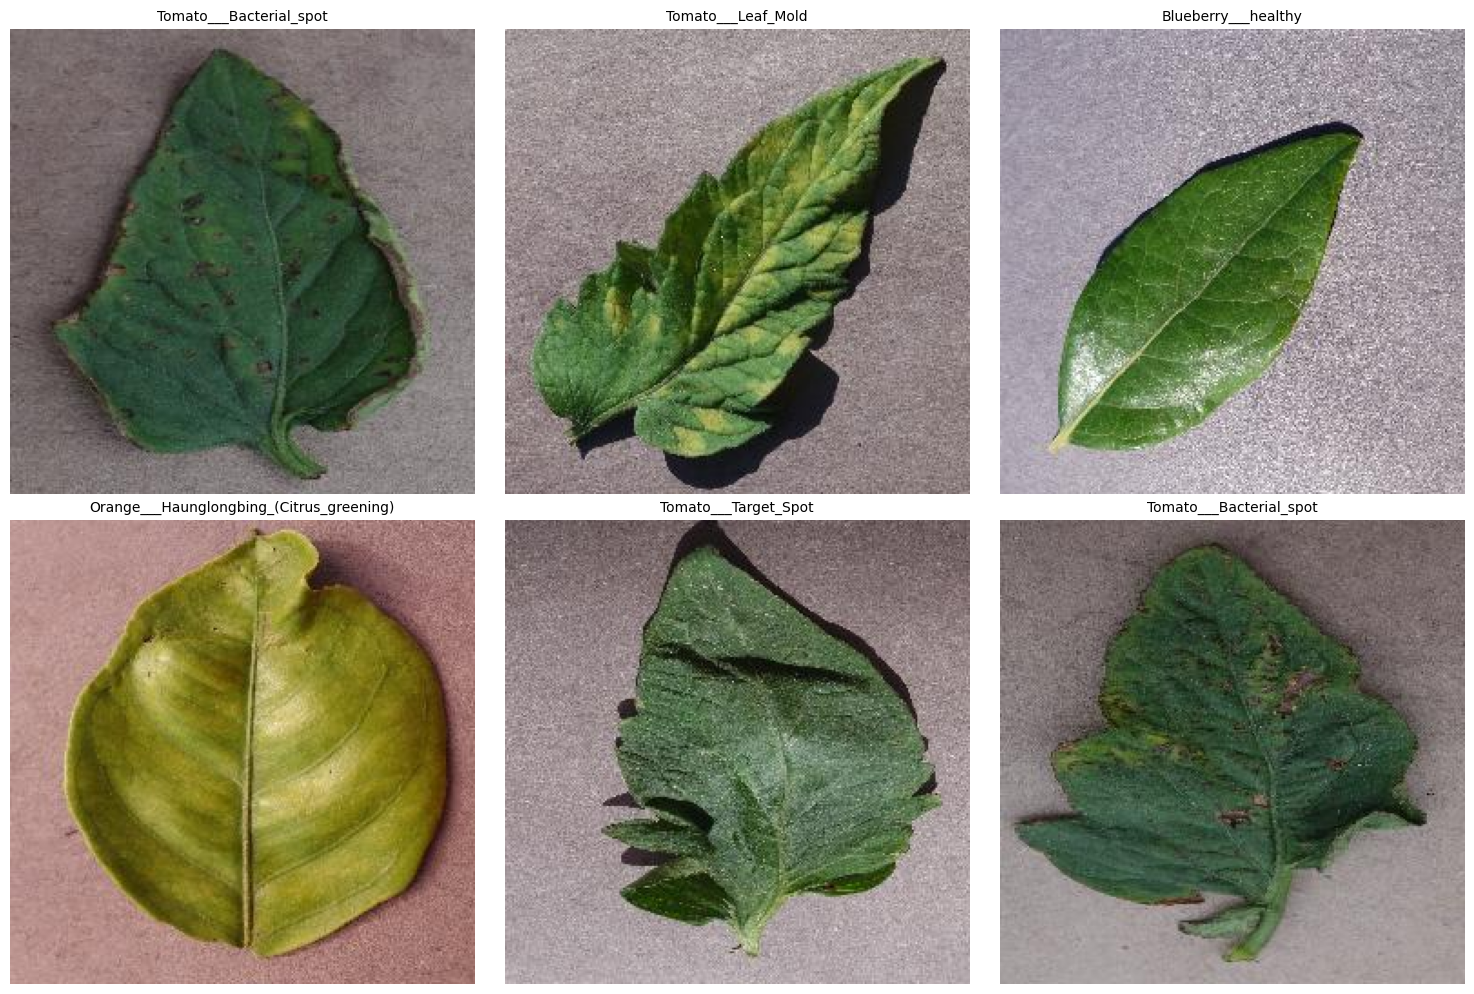

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Pick 6 random samples
if len(df) >= 6:
    samples = df.sample(6)
    plt.figure(figsize=(15, 10))

    for i, (index, row) in enumerate(samples.iterrows()):
        plt.subplot(2, 3, i + 1)
        # Read the image using OpenCV
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.title(row['label'], fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough images found yet. Please check your dataset extraction.")

In [ ]:
from torchvision import transforms

# ImageNet normalization stats
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


In [ ]:
from torchvision import datasets

train_dataset = datasets.ImageFolder("/content/dataset/PlantVillage/train", transform=train_transform)
val_dataset   = datasets.ImageFolder("/content/dataset/PlantVillage/val", transform=val_transform)

print(train_dataset.classes)  # folder names become class labels


['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [ ]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

# Count samples per class
class_counts = torch.bincount(torch.tensor(train_dataset.targets))
class_weights = 1. / class_counts.float()
sample_weights = [class_weights[label] for label in train_dataset.targets]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

**DATALOADERS CREATION**

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,   # handles imbalance
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
print("Train loader:", len(train_loader), "batches")
print("Val loader:", len(val_loader), "batches")



Train loader: 1358 batches
Val loader: 340 batches


HANDLE CLASS IMBALANCE

In [ ]:
from collections import Counter

train_labels = [label for _, label in train_dataset]
class_counts = Counter(train_labels)

num_classes = len(train_dataset.classes)

total_samples = sum(class_counts.values())

class_weights = [
    total_samples / class_counts[i]
    for i in range(num_classes)
]

class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)


Class weights: tensor([ 86.1984,  87.5887, 197.4727,  33.0122,  36.1431,  51.5962,  63.5146,
        105.9610,  45.5866,  55.1320,  46.7643,  46.0212,  39.2448,  50.4576,
        128.1534,   9.8624,  23.6366, 150.8472,  54.5094,  36.7236,  54.3050,
         54.3050, 359.0413, 146.2761,  10.6690,  29.5940,  48.9786, 119.3516,
         25.5253,  54.3050,  28.4506,  57.0880,  30.6591,  32.3967,  38.6857,
         10.1363, 145.2977,  34.1273])


**VERIFY PREPROCESSING PIPELINE**

In [ ]:
train_images, train_labels = next(iter(train_loader))
val_images, val_labels = next(iter(val_loader))

print("TRAIN BATCH")
print("Images shape:", train_images.shape)
print("Labels shape:", train_labels.shape)
print("Dtype:", train_images.dtype)
print("Value range:", train_images.min().item(), train_images.max().item())

print("\nVAL BATCH")
print("Images shape:", val_images.shape)
print("Labels shape:", val_labels.shape)
print("Value range:", val_images.min().item(), val_images.max().item())

TRAIN BATCH
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Dtype: torch.float32
Value range: -2.1179039478302 2.640000104904175

VAL BATCH
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Value range: -2.1007792949676514 2.640000104904175


DENORMALIZATION

In [ ]:
def denormalize(tensor, mean=imagenet_mean, std=imagenet_std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

**VISUALIZE DATA AUGMENTATION EFFECTS**

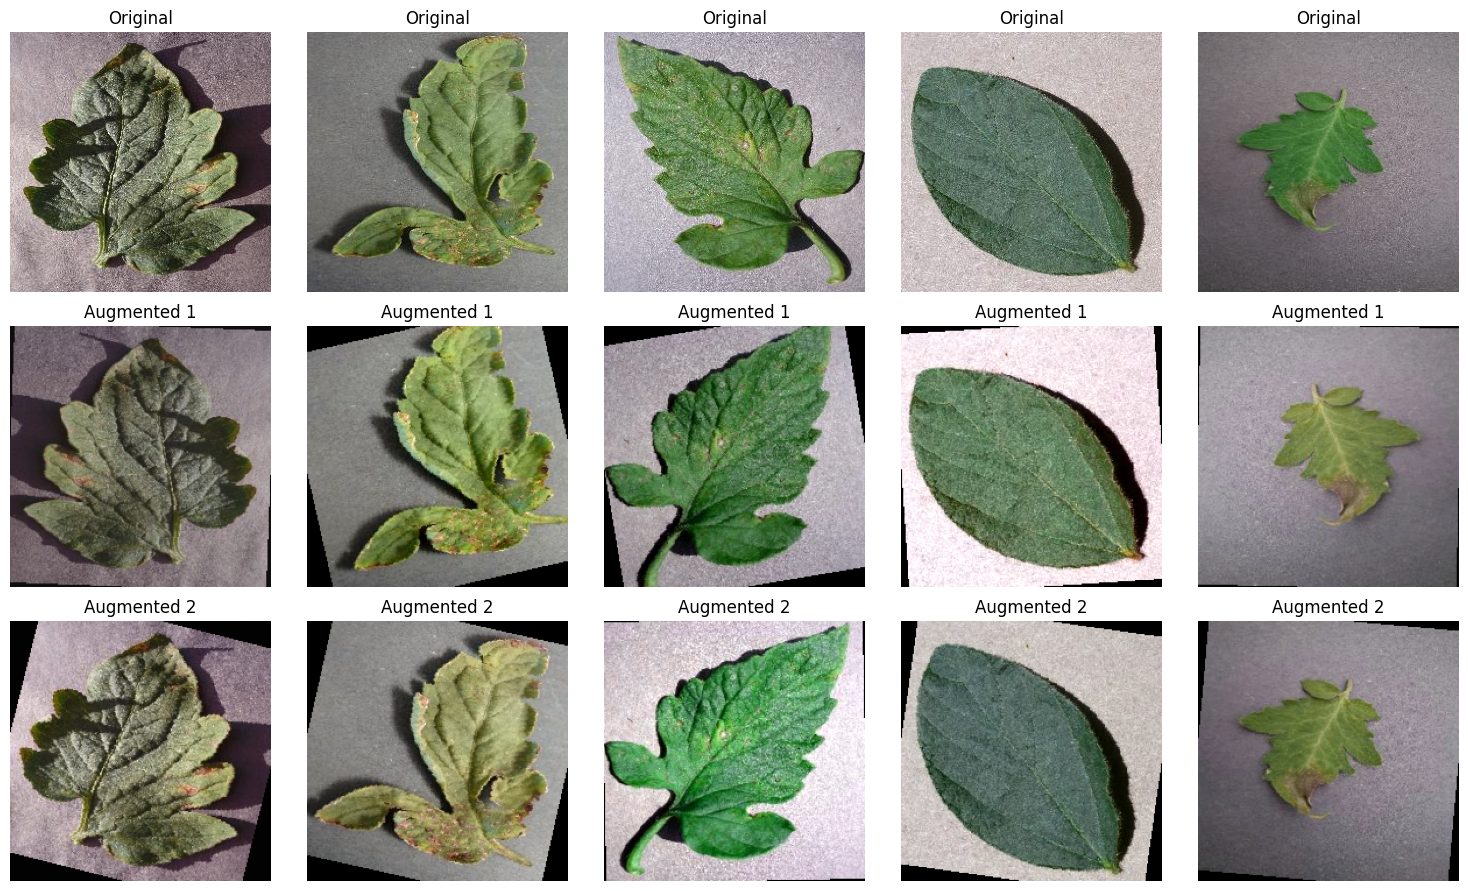

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Pick 6 random samples
if len(train_dataset) >= 5:
    # Using train_dataset as df might contain validation images as well
    # np.random.seed(42) already set, so this line is redundant if not sampling from df
    indices = np.random.choice(len(train_dataset), 5, replace=False)

    fig, axes = plt.subplots(3, 5, figsize=(15, 9))

    for col, idx in enumerate(indices):
        img_path, _ = train_dataset.samples[idx]
        original = Image.open(img_path)

        axes[0, col].imshow(original)
        axes[0, col].set_title("Original")
        axes[0, col].axis("off")

        # Apply transform directly from train_transform and denormalize
        aug1 = denormalize(train_transform(original).clone()).permute(1, 2, 0)
        axes[1, col].imshow(aug1)
        axes[1, col].set_title("Augmented 1")
        axes[1, col].axis("off")

        aug2 = denormalize(train_transform(original).clone()).permute(1, 2, 0)
        axes[2, col].imshow(aug2)
        axes[2, col].set_title("Augmented 2")
        axes[2, col].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Not enough images found in train_dataset for visualization.")

# Visualize Sample Batches from Train and Validation Loaders

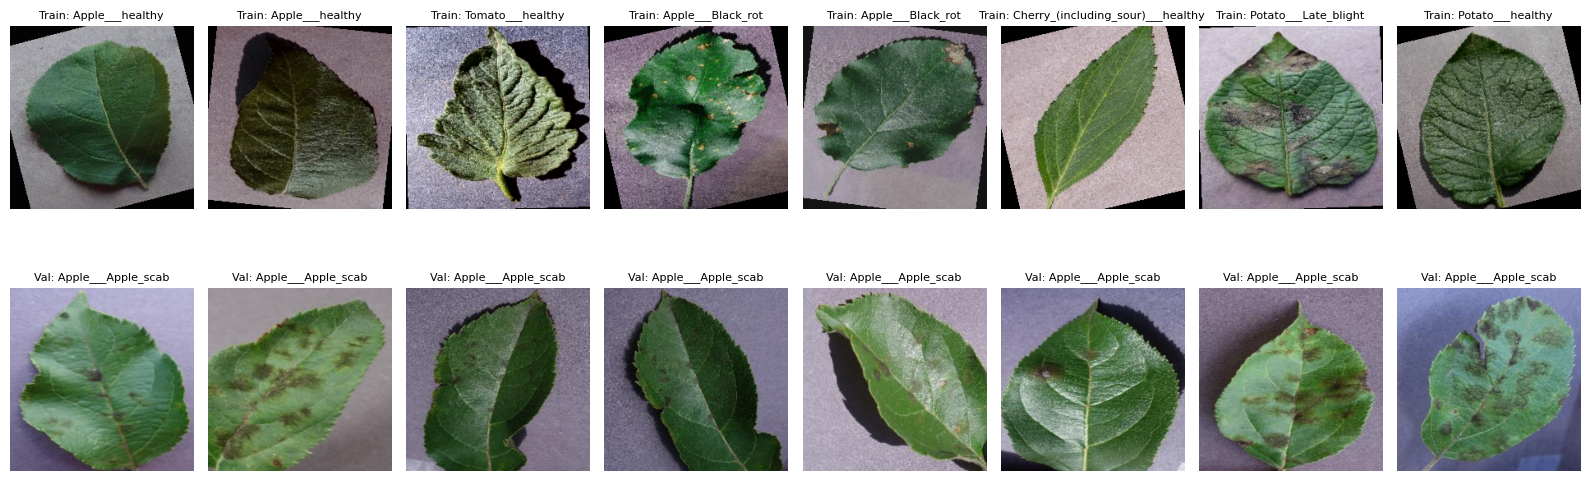

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(16, 6))

train_imgs, train_lbls = next(iter(train_loader))
val_imgs, val_lbls = next(iter(val_loader))

# Define class_names from the dataset
class_names = train_dataset.classes

for i in range(8):
    img = denormalize(train_imgs[i].clone()).permute(1, 2, 0)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Train: {class_names[train_lbls[i]]}", fontsize=8)
    axes[0, i].axis("off")

    img = denormalize(val_imgs[i].clone()).permute(1, 2, 0)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Val: {class_names[val_lbls[i]]}", fontsize=8)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()